In [12]:
import torch
import torch
import torch.nn as nn

import numpy as np
import sys
import os
import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv4

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

class SymbolClassifier(nn.Module):
    def __init__(self,mean,std):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean))
        self.register_buffer("std", torch.tensor(std))

        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512)
        )

    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.net(x)  # logits

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dummy_mean = torch.zeros(16)
dummy_std  = torch.ones(16)
model = SymbolClassifier(dummy_mean,dummy_std).to(device)
model.load_state_dict(torch.load("symbol_classifier.pt", map_location=device))

model.eval()   # 🔴 VERY IMPORTANT

sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 16

## HOW TO LOAD WEIGHT
layers = [input_col * input_row, second_layer, third_layer] # <-- must match training

multi_bam = MultiBAMv4(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam.bams):
    w_np = np.load(f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")
    

TypeError: SymbolClassifier.__init__() missing 2 required positional arguments: 'mean' and 'std'

seed :  496
(1, 16)
[-13.023153     7.4742794   -4.092225    -8.5959215  -11.548354
   0.65105134  -2.7986054    9.487246     1.5859091   -2.3795407
   5.234702   -12.271954     3.5143986   -3.7296314   -5.163597
   2.199799  ]
Predicted symbol: 101
(512, 33)


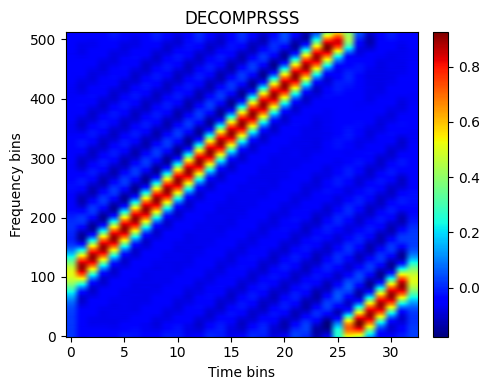

In [ ]:
symbol1 = 100
# EXAMPLE OF COMPRESS and DECOMPRESS
random_ = np.random.randint(1, 999)  # integer from 1 to 10 (inclusive)
print("seed : ",random_)
seed = random_
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

snr = 30
x = lora_init.awgn_iq_with_seed(x1,snr,seed)

input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
flat = input_spec.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 

out1 = multi_bam.compress(flat)
print(out1.shape)
a = out1.squeeze() 
print(a)

x = torch.tensor(a, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    pred = torch.argmax(logits, dim=1)

print("Predicted symbol:", pred.item())

out2 = multi_bam.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [reco_spec]

show_multiple_spectrograms(array_a,["DECOMPRSSS"],1)